# Лабораторная работа №1. Работа с данными

**Датасет:** `ID_data_mass_18122012.xlsx`, лист `VU`.

**Цель:** очистить данные и отобрать признаки.

**Целевые переменные:** `G_total` и `КГФ`.

Расчёты на `pandas`, `numpy`, `matplotlib` без библиотек ML. Энтропия и gain ratio считаются вручную.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

## 1. Загрузка данных

В файле два уровня заголовков (группа и название колонки) плюс отдельная строка с единицами измерения. Читаем шапку из двух строк, а строку с единицами просто пропускаем.

In [ ]:
df_raw = pd.read_excel('ID_data_mass_18122012.xlsx', sheet_name='VU', header=[0, 1])
print('Размер сырых данных:', df_raw.shape)
df_raw.head(3)

Размер сырых данных: (186, 34)


Unnamed: 0_level_0   Unnamed: 1_level_0 Unnamed: 2_level_0  \
  Unnamed: 0_level_1   Unnamed: 1_level_1  Глубина манометра   
0                  №           дд.мм.гггг                  м   
1                804  2008-06-05 00:00:00             3576.3   
2                804  2008-06-06 00:00:00             3576.3   

  Unnamed: 3_level_0 осредненные параметры               На конец режима  \
                 Dшт                  Руст   Рзаб   Pлин            Руст   
0                 мм                  бара   бара   бара             бар   
1               7.94                 249.6  370.1  101.8             249   
2               9.53                 233.5  364.6  101.3             231   

                 ...     Линейные условия                                    \
    Рзаб   Рлин  ... Рпл. Тек (Карноухов)   Pсб      Pсб.1      Ro_g   Ro_c   
0    бар    бар  ...                  МПа   атм        бар     кг/м3  кг/м3   
1  359.6  101.8  ...                    -  93.6  92.376018  0.806017    801   
2  338.1  102.4  ...                    -  92.9  91.685171  0.806017    801   

                                                                 
    Ro_w Удельная плотность газа    G_total       КГФ     КГФ.1  
0  кг/м3                      б/р      кг/с      г/м3  т/тыс.м3  
1   1000                 0.669449  2.782623  311.9094       NaN  
2   1000                 0.669449  3.697781  288.6003       NaN  

[3 rows x 34 columns]

Склеим двухуровневые названия колонок в одно. Для группы добавим короткий префикс: `avg_` для осреднённых, `end_` для значений на конец режима, `std_` для стандартных условий, `lin_` для линейных.


In [ ]:
group_prefix = {
    'осредненные параметры': 'avg',
    'На конец режима': 'end',
    'Стандартные условия': 'std',
    'Линейные условия': 'lin',
}

def make_name(top, sub):
    top, sub = str(top), str(sub)
    if 'Unnamed' in sub:
        return top
    if 'Unnamed' in top:
        return sub
    return f"{group_prefix.get(top, top)}_{sub}"

df = df_raw.copy()
df.columns = [make_name(t, s) for t, s in df_raw.columns]
df = df.iloc[1:].reset_index(drop=True)
print('Колонки:')
for c in df.columns:
    print(' -', c)

Колонки:
 - Unnamed: 0_level_0
 - Unnamed: 1_level_0
 - Глубина манометра
 - Dшт
 - avg_Руст
 - avg_Рзаб
 - avg_Pлин
 - end_Руст
 - end_Рзаб
 - end_Рлин
 - end_Туст
 - end_Тна шлейфе
 - end_Тзаб
 - end_Tлин
 - std_Дебит газа
 - std_Дебит ст. конд.
 - std_Дебит воды
 - std_Дебит смеси
 - lin_Дебит гааз
 - lin_Дебит кон нестабильный
 - lin_Дебит воды
 - lin_Нэф
 - lin_Рпл. Тек (послед точка на КВД)
 - lin_Рпл. Тек (Расчет по КВД)
 - lin_Рпл. Тек (Карноухов)
 - lin_Pсб
 - lin_Pсб.1
 - lin_Ro_g
 - lin_Ro_c
 - lin_Ro_w
 - lin_Удельная плотность газа 
 - lin_G_total
 - lin_КГФ
 - lin_КГФ.1


## 2. Первичная чистка

- убрать колонки `№` и дату: это идентификаторы строки, а не признаки;
- объединить `lin_КГФ` и `lin_КГФ.1` в одну целевую переменную;
- привести все колонки к числовому типу (всё, что не парсится заменить на NaN).


In [ ]:
df = df.drop(columns=df.columns[:2].tolist())

df['lin_КГФ'] = pd.to_numeric(df['lin_КГФ'], errors='coerce')
df['lin_КГФ.1'] = pd.to_numeric(df['lin_КГФ.1'], errors='coerce')
df['lin_КГФ'] = df['lin_КГФ'].fillna(df['lin_КГФ.1'] * 1000)
df = df.drop(columns=['lin_КГФ.1'])

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.rename(columns={'lin_G_total': 'G_total', 'lin_КГФ': 'КГФ'})

print('Размер:', df.shape)
df.head()

Размер: (185, 31)


,Глубина манометра,Dшт,avg_Руст,avg_Рзаб,avg_Pлин,end_Руст,end_Рзаб,end_Рлин,end_Туст,end_Тна шлейфе,...,lin_Рпл. Тек (Расчет по КВД),lin_Рпл. Тек (Карноухов),lin_Pсб,lin_Pсб.1,lin_Ro_g,lin_Ro_c,lin_Ro_w,lin_Удельная плотность газа,G_total,КГФ
0,3576.3,7.94,249.6,370.1,101.8,249.0,359.6,101.8,53.0,31.7,...,56.5,NaN,93.6,92.376018,0.806017,801.0,1000.0,0.669449,2.782623,311.9094
1,3576.3,9.53,233.5,364.6,101.3,231.0,338.1,102.4,58.8,37.6,...,56.5,NaN,92.9,91.685171,0.806017,801.0,1000.0,0.669449,3.697781,288.6003
2,3576.3,11.11,213.4,357.1,101.6,211.0,314.8,100.6,63.6,42.8,...,56.5,NaN,91.4,90.204787,0.806017,801.0,1000.0,0.669449,4.515073,248.7906
3,3576.3,12.70,191.6,347.4,98.4,187.0,291.5,99.0,64.7,46.2,...,56.5,NaN,89.2,88.033555,0.806017,801.0,1000.0,0.669449,5.217673,223.5591
4,3576.3,14.29,171.9,337.7,99.2,169.0,270.3,99.5,64.0,49.4,...,56.5,NaN,89.7,88.527017,0.806017,801.0,1000.0,0.669449,5.765092,215.1486


## 3. Удаляем строки без целевых значений

По заданию: если **обе** целевых пустые, строка для обучения бесполезна.


In [ ]:
before = len(df)
mask = df['G_total'].notna() | df['КГФ'].notna()
df = df[mask].reset_index(drop=True)
print(f'Было строк: {before}, осталось: {len(df)} (удалено {before - len(df)})')
print('Из них с непустым G_total:', df['G_total'].notna().sum())
print('Из них с непустым КГФ   :', df['КГФ'].notna().sum())

Было строк: 185, осталось: 93 (удалено 92)
Из них с непустым G_total: 23
Из них с непустым КГФ   : 93


## 4. Сохраняем названия признаков

In [ ]:
targets = ['G_total', 'КГФ']
features = [c for c in df.columns if c not in targets]

print(f'Признаков: {len(features)}')
for f in features:
    print(' -', f)

Признаков: 29
 - Глубина манометра
 - Dшт
 - avg_Руст
 - avg_Рзаб
 - avg_Pлин
 - end_Руст
 - end_Рзаб
 - end_Рлин
 - end_Туст
 - end_Тна шлейфе
 - end_Тзаб
 - end_Tлин
 - std_Дебит газа
 - std_Дебит ст. конд.
 - std_Дебит воды
 - std_Дебит смеси
 - lin_Дебит гааз
 - lin_Дебит кон нестабильный
 - lin_Дебит воды
 - lin_Нэф
 - lin_Рпл. Тек (послед точка на КВД)
 - lin_Рпл. Тек (Расчет по КВД)
 - lin_Рпл. Тек (Карноухов)
 - lin_Pсб
 - lin_Pсб.1
 - lin_Ro_g
 - lin_Ro_c
 - lin_Ro_w
 - lin_Удельная плотность газа 


## 5. Описательная статистика

In [ ]:
desc = df.describe().T
desc['n_missing'] = df.isna().sum()
desc['missing_%'] = (df.isna().mean() * 100).round(1)
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'n_missing', 'missing_%']]
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,n_missing,missing_%
Глубина манометра,90.0,3524.087,144.475,3276.000,3427.625,3579.000,3652.250,3670.000,3,3.2
Dшт,93.0,10.951,2.423,6.350,9.530,11.110,12.700,15.880,0,0.0
avg_Руст,93.0,228.293,41.897,138.158,201.637,229.895,252.000,337.108,0,0.0
avg_Рзаб,90.0,331.762,56.481,174.000,297.798,337.789,364.150,458.600,3,3.2
avg_Pлин,93.0,99.861,7.301,73.307,95.946,100.800,103.865,121.683,0,0.0
end_Руст,93.0,227.644,41.757,136.000,200.000,228.000,252.000,333.000,0,0.0
end_Рзаб,90.0,330.334,56.357,174.000,294.625,334.250,362.150,458.500,3,3.2
end_Рлин,93.0,98.005,12.426,40.740,95.335,100.260,104.000,123.617,0,0.0
end_Туст,93.0,56.172,11.251,24.200,50.300,58.000,64.000,75.000,0,0.0
end_Тна шлейфе,60.0,43.092,19.602,14.000,33.300,38.700,46.375,110.200,33,35.5


## 6. Распределения признаков с квартилями

Для каждого признака рисуем гистограмму. Q1 красным, Q3 зелёным.


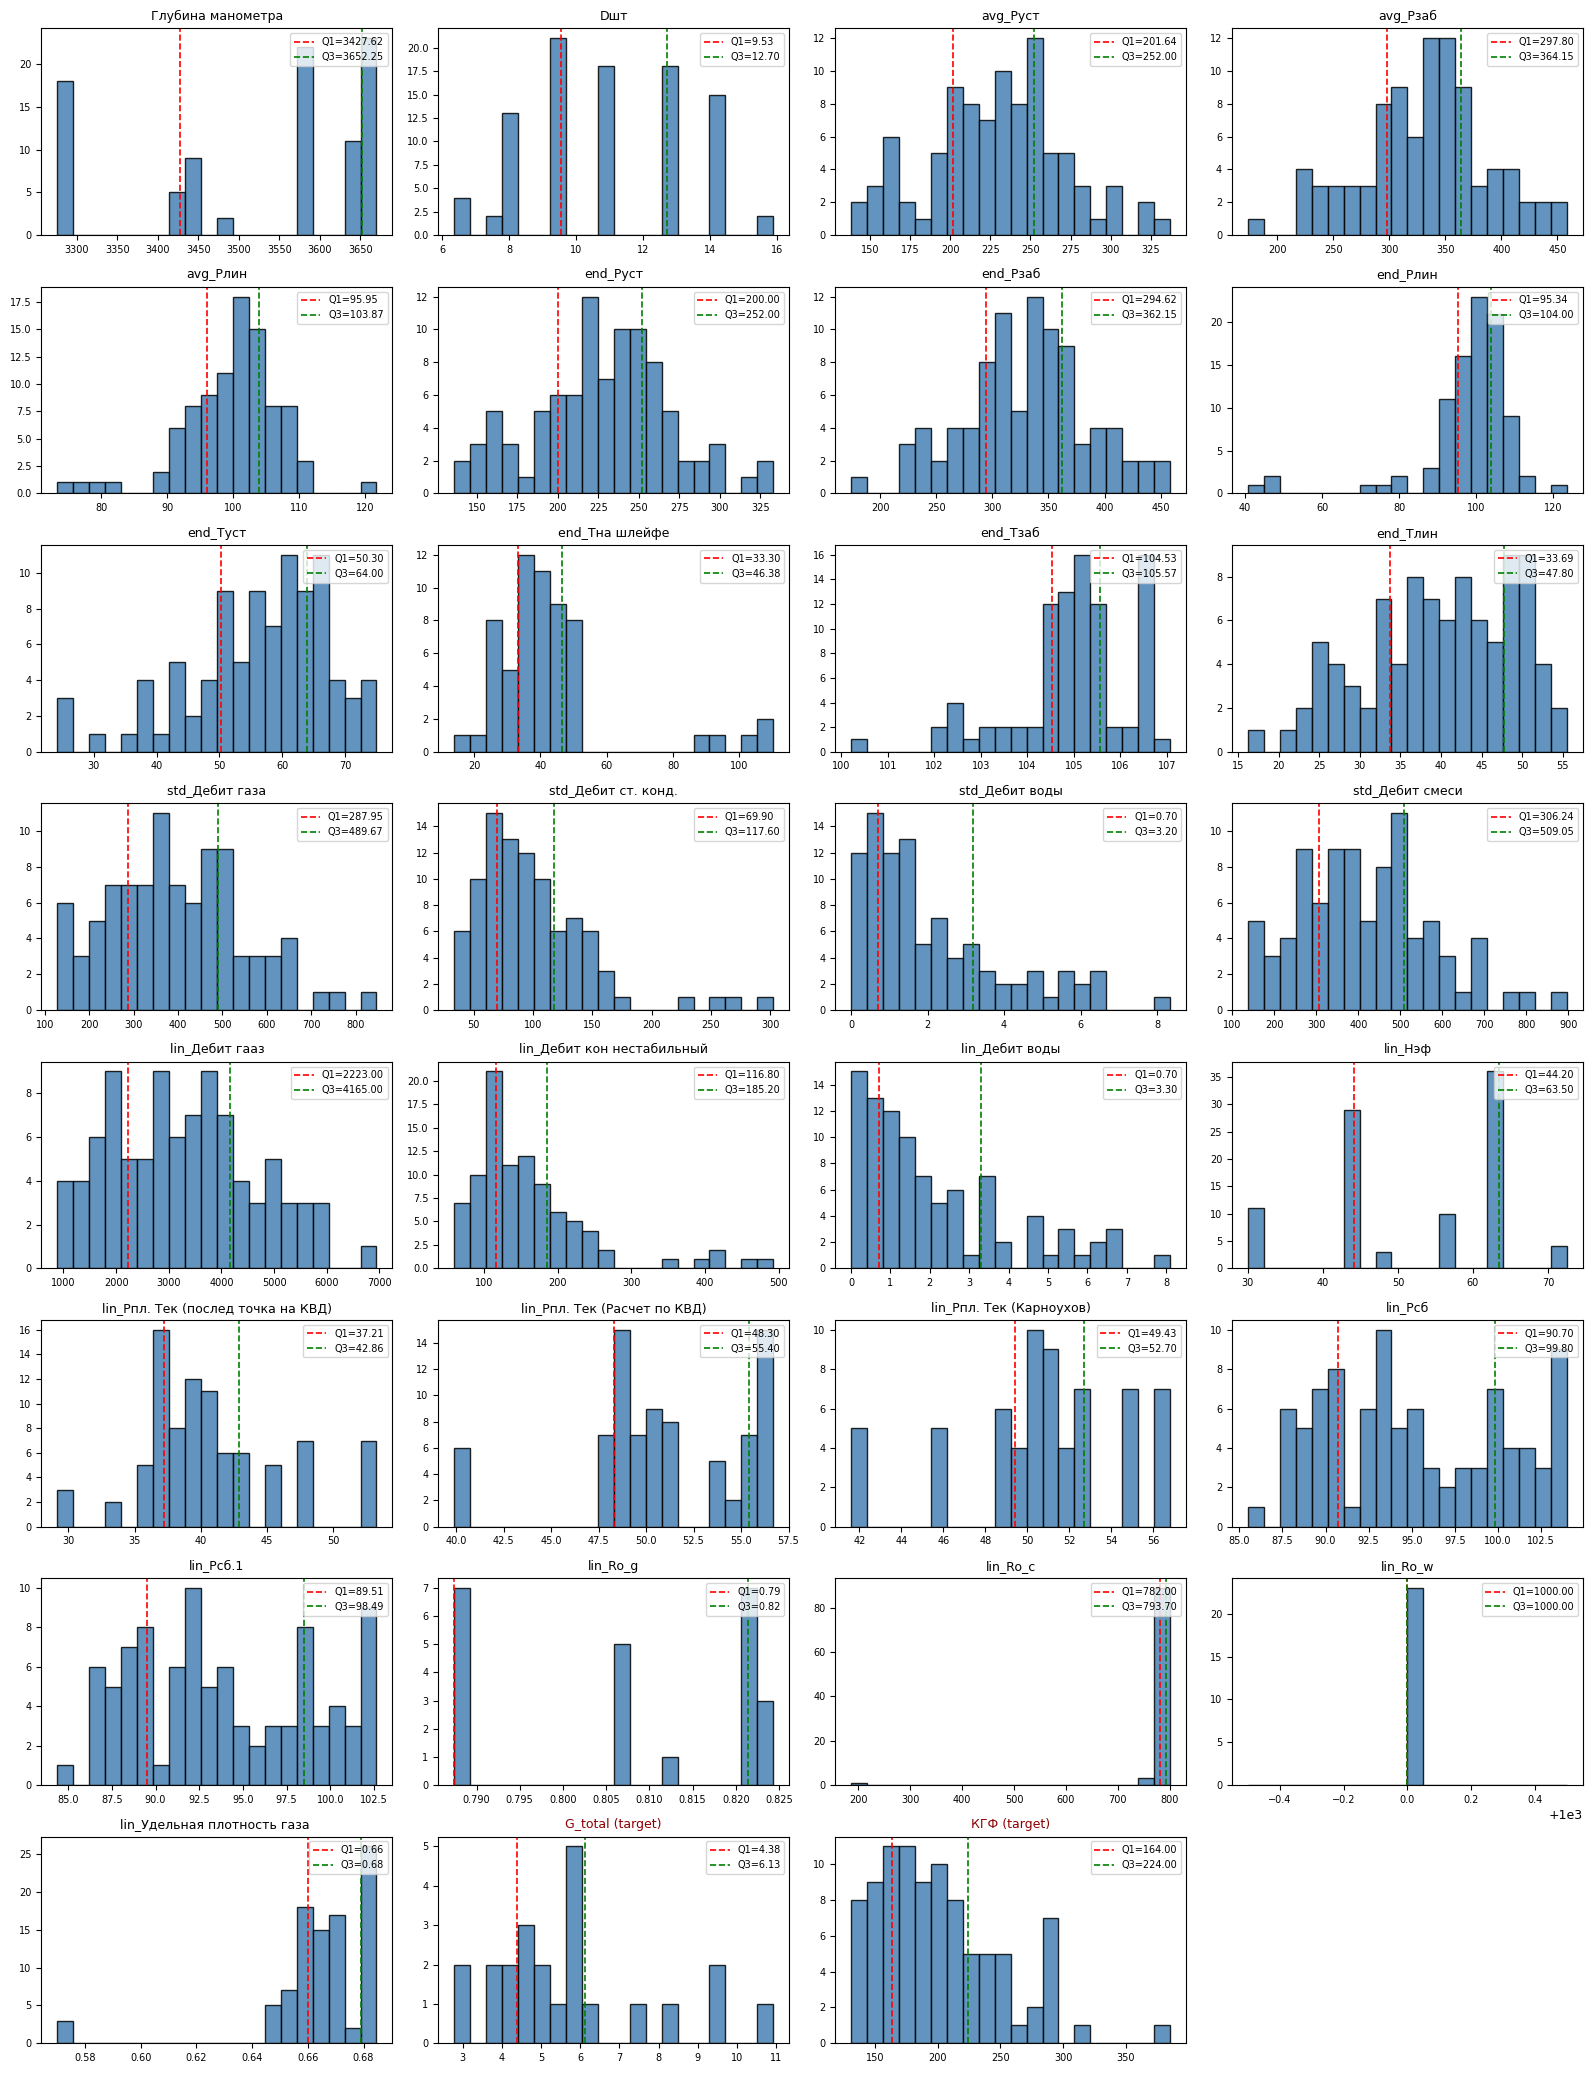

In [ ]:
all_cols = features + targets
ncols = 4
nrows = (len(all_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.6))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    data = df[col].dropna()
    if len(data) == 0:
        ax.set_title(f'{col} (пусто)')
        ax.axis('off')
        continue
    ax.hist(data, bins=20, color='steelblue', edgecolor='black', alpha=0.85)
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    ax.axvline(q1, color='red', linestyle='--', linewidth=1.2, label=f'Q1={q1:.2f}')
    ax.axvline(q3, color='green', linestyle='--', linewidth=1.2, label=f'Q3={q3:.2f}')
    is_target = col in targets
    ax.set_title(f'{col}' + (' (target)' if is_target else ''),
                 fontsize=9, color='darkred' if is_target else 'black')
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(axis='both', labelsize=7)

for j in range(len(all_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 7. Корреляции (по модулю)

Считаем матрицу корреляций Пирсона для всех признаков и целевых, берём по модулю.


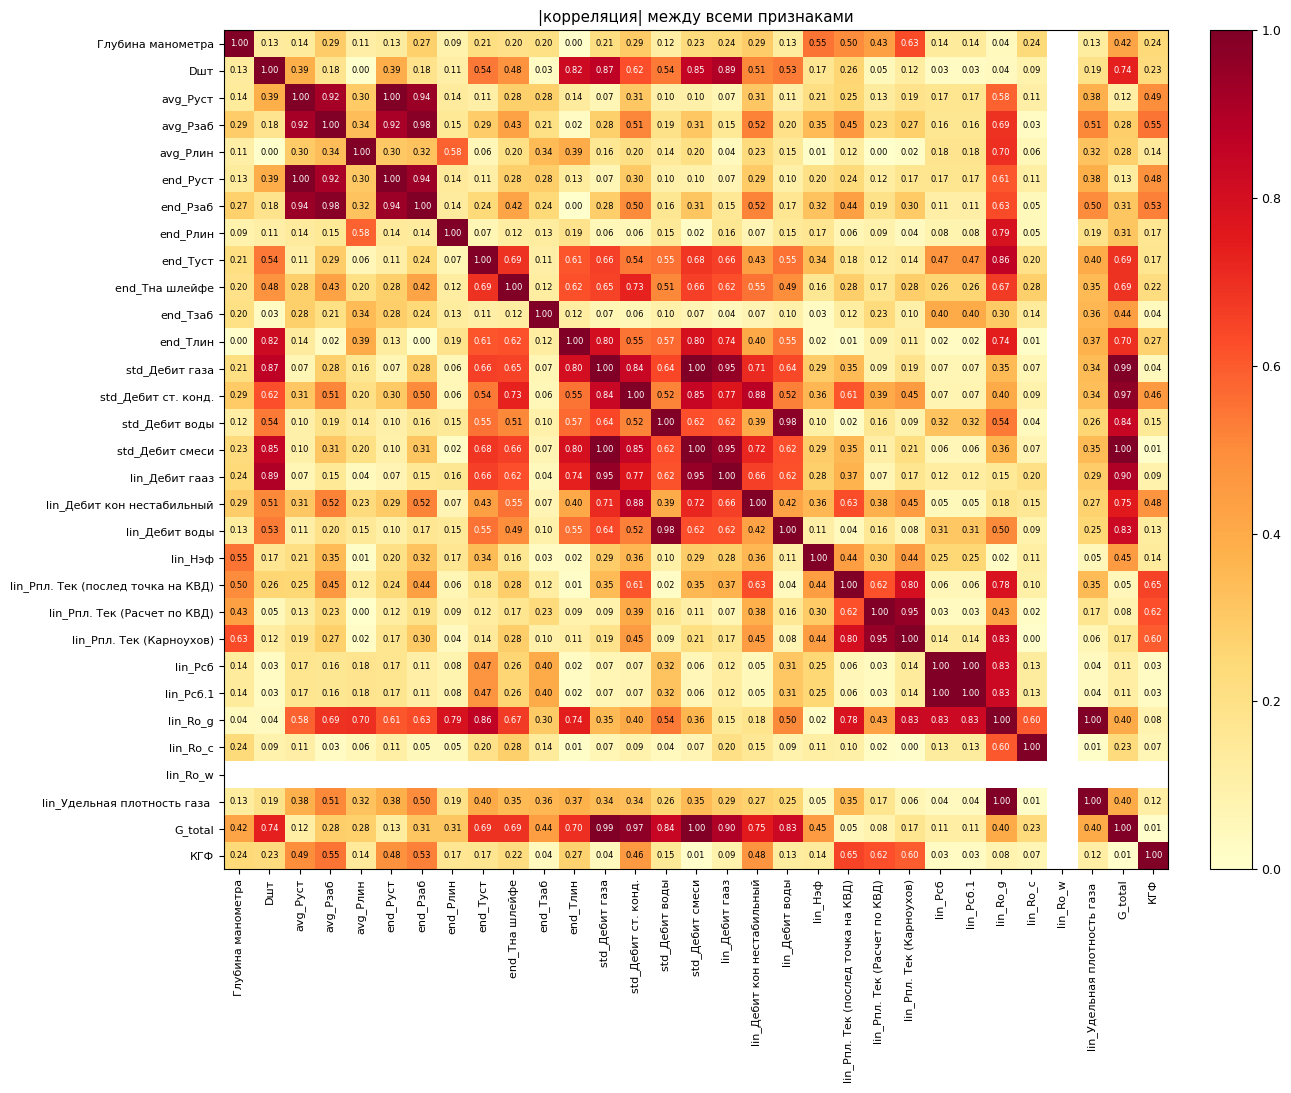

In [ ]:
corr = df.corr().abs()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if v > 0.55 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('|корреляция| между всеми признаками')
plt.tight_layout()
plt.show()

In [ ]:
corr_with_target = corr[targets].drop(index=targets).sort_values('G_total', ascending=False)
corr_with_target.round(3)

,G_total,КГФ
std_Дебит смеси,0.996,0.007
std_Дебит газа,0.993,0.045
std_Дебит ст. конд.,0.967,0.459
lin_Дебит гааз,0.901,0.087
std_Дебит воды,0.842,0.151
lin_Дебит воды,0.828,0.126
lin_Дебит кон нестабильный,0.750,0.475
Dшт,0.735,0.232
end_Tлин,0.699,0.271
end_Тна шлейфе,0.691,0.219


## 8. Важность признаков по gain_ratio

Gain ratio это нормированный прирост информации:

$$ GR(Y, X) = \frac{IG(Y, X)}{H(X)} = \frac{H(Y) - H(Y|X)}{H(X)} $$

Поскольку и признаки, и таргет непрерывные, дискретизируем их на бины с равной частотой через `pd.qcut`. Логарифм по основанию 2 (биты).


In [ ]:
def entropy(arr):
    """Энтропия"""
    _, counts = np.unique(arr, return_counts=True)
    p = counts / counts.sum()
    return float(-np.sum(p * np.log2(p + 1e-12)))


def conditional_entropy(x_bins, y_bins):
    """Остаточная энтропия H(Y|X)"""
    h = 0.0
    n = len(x_bins)
    for v in np.unique(x_bins):
        mask = x_bins == v
        h += (mask.sum() / n) * entropy(y_bins[mask])
    return h


def gain_ratio(feature, target, n_bins=10):
    """Gain Ratio = (H(Y) - H(Y|X)) / H(X)"""
    pair = pd.DataFrame({'x': feature, 'y': target}).dropna()
    if len(pair) < 5:
        return np.nan
    nb_x = min(n_bins, pair['x'].nunique())
    nb_y = min(n_bins, pair['y'].nunique())
    if nb_x < 2 or nb_y < 2:
        return 0.0
    try:
        x_bins = pd.qcut(pair['x'], q=nb_x, duplicates='drop', labels=False).values
        y_bins = pd.qcut(pair['y'], q=nb_y, duplicates='drop', labels=False).values
    except ValueError:
        return np.nan
    h_y = entropy(y_bins)
    h_y_given_x = conditional_entropy(x_bins, y_bins)
    h_x = entropy(x_bins)
    if h_x == 0:
        return 0.0
    return (h_y - h_y_given_x) / h_x


test = pd.Series(np.random.RandomState(0).randn(200))
print('Sanity check gain_ratio(x, x):', round(gain_ratio(test, test), 3))

Sanity check gain_ratio(x, x): 1.0


In [ ]:
gr_g = {f: gain_ratio(df[f], df['G_total']) for f in features}
gr_k = {f: gain_ratio(df[f], df['КГФ']) for f in features}

gr_df = pd.DataFrame({'G_total': gr_g, 'КГФ': gr_k})
gr_df['mean'] = gr_df.mean(axis=1)
gr_df = gr_df.sort_values('mean', ascending=True)
gr_df.round(3)

,G_total,КГФ,mean
lin_Ro_w,0.000,0.000,0.000
lin_Нэф,-0.000,0.321,0.161
avg_Pлин,0.627,0.214,0.420
lin_Удельная плотность газа,0.581,0.266,0.424
lin_Pсб.1,0.653,0.229,0.441
lin_Pсб,0.653,0.229,0.441
end_Рлин,0.680,0.214,0.447
lin_Рпл. Тек (Расчет по КВД),0.561,0.343,0.452
lin_Дебит воды,0.669,0.266,0.467
lin_Ro_c,0.568,0.370,0.469


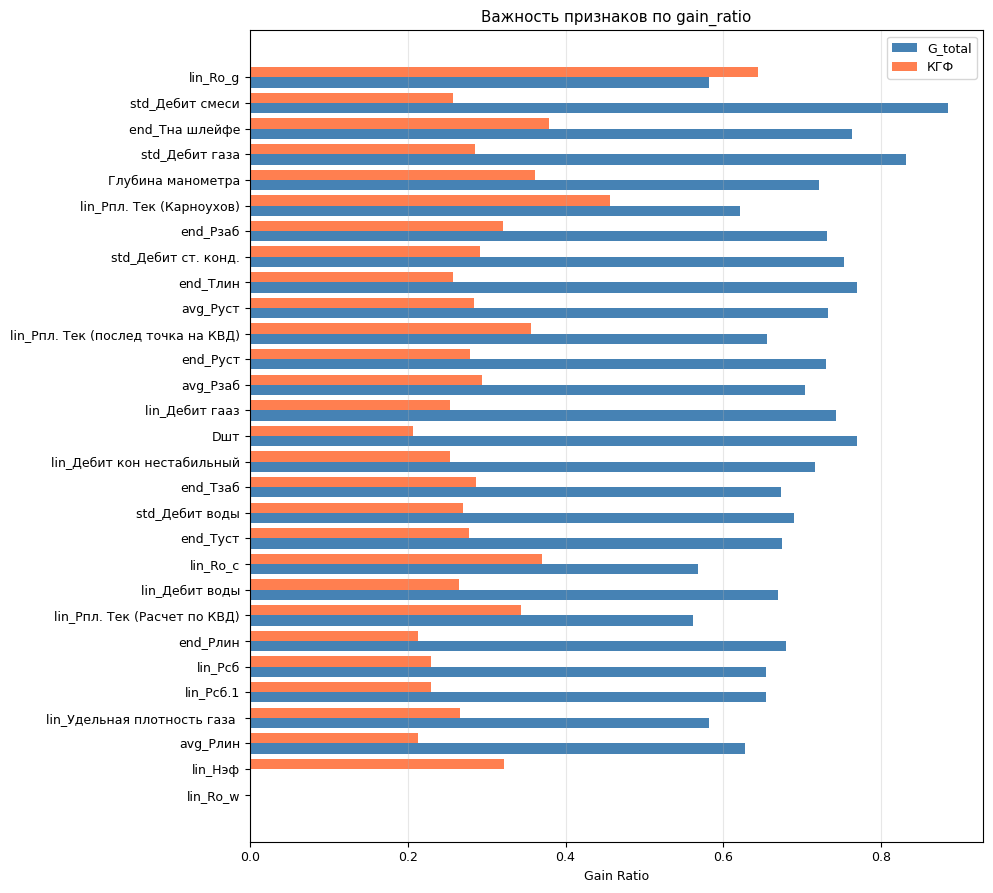

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(gr_df))
ax.barh(y - 0.2, gr_df['G_total'].values, height=0.4, color='steelblue', label='G_total')
ax.barh(y + 0.2, gr_df['КГФ'].values,    height=0.4, color='coral',     label='КГФ')
ax.set_yticks(y)
ax.set_yticklabels(gr_df.index)
ax.set_xlabel('Gain Ratio')
ax.set_title('Важность признаков по gain_ratio')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
to_drop = [
    'lin_Ro_w',
    'lin_Ro_g',
    'lin_Pсб.1',
    'avg_Руст', 'avg_Рзаб', 'avg_Pлин',
    'lin_Рпл. Тек (Карноухов)',
    'lin_Рпл. Тек (послед точка на КВД)',
    'std_Дебит смеси',
    'lin_Дебит гааз', 'lin_Дебит воды', 'lin_Дебит кон нестабильный',
    'Глубина манометра',
]
to_keep = [c for c in features if c not in to_drop]

print(f'Оставляем {len(to_keep)} признаков из {len(features)}:')
for f in to_keep:
    print(' +', f)
print()
print(f'Удаляем {len(to_drop)}:')
for f in to_drop:
    print(' -', f)

Оставляем 16 признаков из 29:
 + Dшт
 + end_Руст
 + end_Рзаб
 + end_Рлин
 + end_Туст
 + end_Тна шлейфе
 + end_Тзаб
 + end_Tлин
 + std_Дебит газа
 + std_Дебит ст. конд.
 + std_Дебит воды
 + lin_Нэф
 + lin_Рпл. Тек (Расчет по КВД)
 + lin_Pсб
 + lin_Ro_c
 + lin_Удельная плотность газа 

Удаляем 13:
 - lin_Ro_w
 - lin_Ro_g
 - lin_Pсб.1
 - avg_Руст
 - avg_Рзаб
 - avg_Pлин
 - lin_Рпл. Тек (Карноухов)
 - lin_Рпл. Тек (послед точка на КВД)
 - std_Дебит смеси
 - lin_Дебит гааз
 - lin_Дебит воды
 - lin_Дебит кон нестабильный
 - Глубина манометра


## 9. Выбросы и пропуски

Делаем **после** расчёта корреляций и важности: иначе заполненные медианой пропуски исказили бы сигналы.

**Выбросы.** Правило 1.5·IQR: всё, что выходит за `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`, заменяем на NaN. Сразу медианой не заменяем, потому что тогда медиана пересчитывалась бы в цикле уже на залатанных данных.

In [ ]:
df_clean = df[to_keep + targets].copy()

outlier_counts = {}
for col in to_keep:
    s = df_clean[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (s < lo) | (s > hi)
    outlier_counts[col] = int(is_outlier.sum())
    df_clean.loc[is_outlier, col] = np.nan

outlier_report = pd.Series(outlier_counts, name='n_outliers').sort_values(ascending=False)
print('Помечено выбросов по правилу 1.5·IQR:')
print(outlier_report[outlier_report > 0])

Помечено выбросов по правилу 1.5·IQR:
end_Рлин                        8
end_Тзаб                        8
end_Тна шлейфе                  5
std_Дебит ст. конд.             4
end_Туст                        3
lin_Удельная плотность газа     3
end_Руст                        1
end_Рзаб                        1
std_Дебит газа                  1
std_Дебит воды                  1
lin_Ro_c                        1
Name: n_outliers, dtype: int64


In [ ]:
for col in to_keep:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Пропуски в признаках после заполнения:')
print(df_clean[to_keep].isna().sum().sum(), 'всего NaN')
print()
print('Пропуски в таргетах (намеренно оставлены):')
print(df_clean[targets].isna().sum())

Пропуски в признаках после заполнения:
0 всего NaN

Пропуски в таргетах (намеренно оставлены):
G_total    70
КГФ         0
dtype: int64


## 10. Итог

Что получилось после очистки:


In [ ]:
print('Размер очищенного датасета:', df_clean.shape)
print('Признаков:', len(to_keep))
print('Целевых:', len(targets))
df_clean.head()

Размер очищенного датасета: (93, 18)
Признаков: 16
Целевых: 2


,Dшт,end_Руст,end_Рзаб,end_Рлин,end_Туст,end_Тна шлейфе,end_Тзаб,end_Tлин,std_Дебит газа,std_Дебит ст. конд.,std_Дебит воды,lin_Нэф,lin_Рпл. Тек (Расчет по КВД),lin_Pсб,lin_Ro_c,lin_Удельная плотность газа,G_total,КГФ
0,7.94,249.0,359.6,101.8,53.0,31.7,103.2,32.5,214.704,83.6,0.4,56.8,56.5,93.6,801.0,0.669449,2.782623,311.9094
1,9.53,231.0,338.1,102.4,58.8,37.6,103.0,38.6,290.594,104.7,1.4,56.8,56.5,92.9,801.0,0.669449,3.697781,288.6003
2,11.11,211.0,314.8,100.6,63.6,42.8,105.2,43.4,368.042,114.3,1.9,56.8,56.5,91.4,801.0,0.669449,4.515073,248.7906
3,12.70,187.0,291.5,99.0,64.7,46.2,105.2,46.1,434.663,121.3,3.3,56.8,56.5,89.2,801.0,0.669449,5.217673,223.5591
4,14.29,169.0,270.3,99.5,64.0,49.4,104.4,49.9,483.283,129.8,4.6,56.8,56.5,89.7,801.0,0.669449,5.765092,215.1486


In [ ]:
df_clean.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Dшт,93.0,10.951,2.423,6.350,9.530,11.110,12.700,15.880
end_Руст,93.0,226.515,40.271,136.000,200.000,228.000,252.000,325.000
end_Рзаб,93.0,332.233,52.957,216.800,297.500,335.400,359.900,458.500
end_Рлин,93.0,100.559,5.395,86.747,97.000,100.600,103.972,114.700
end_Туст,93.0,57.258,9.715,31.000,51.000,58.900,64.000,75.000
end_Тна шлейфе,93.0,38.087,6.547,14.000,36.300,38.500,39.200,51.800
end_Тзаб,93.0,105.234,0.833,103.000,104.780,105.200,105.560,107.071
end_Tлин,93.0,39.798,8.938,16.205,33.689,40.519,47.800,55.514
std_Дебит газа,93.0,389.378,142.684,128.366,287.950,379.543,488.090,742.114
std_Дебит ст. конд.,93.0,92.210,33.424,33.630,69.900,88.072,114.300,179.764
